In [18]:
import joblib
from tensorflow.keras.models import load_model

# โหลด vectorizer
vectorizer = joblib.load('../../../Features/result/vectorizer-new.pkl')

# ✅ โหลดโมเดลที่บันทึกไว้ (.h5)
final_model = load_model('../models/model_fold_5_new.h5')

# โหลด y_under
y_under = joblib.load('../../../InitData/result/y_under.pkl')

print("✅ โหลดข้อมูลเรียบร้อยแล้ว!")


✅ โหลดข้อมูลเรียบร้อยแล้ว!


In [16]:
new_text = ["LINE ปิดบัญชีผู้ใช้เก่าภายใน 24 ชั่วโมง! กรุณากรอกข้อมูลล็อกอินในลิงก์นี้เพื่อยืนยันตัวตน!"]

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def predict_with_analysis(text, model, vectorizer):
    """Predict and print detailed analysis.

    - Accepts raw text (string).
    - Handles vectorizer outputs that are sparse or dense.
    - Handles model.predict() returning a single array or a list/tuple of arrays.
    - Pads missing aspect outputs with 0.0 so printing/plotting remains stable.
    """
    # Vectorize (robust to sparse/dense)
    X = vectorizer.transform([text])
    try:
        X_arr = X.toarray().astype(np.float32)
    except Exception:
        X_arr = np.asarray(X, dtype=np.float32)

    # Get predictions
    preds = model.predict(X_arr)

    # Normalize to list of scalar probs
    if isinstance(preds, (list, tuple)):
        probs = []
        for p in preds:
            arr = np.asarray(p).ravel()
            probs.append(float(arr[0]) if arr.size > 0 else 0.0)
    else:
        arr = np.asarray(preds).ravel()
        probs = [float(arr[0]) if arr.size > 0 else 0.0]

    # Ensure length 5: main, source, language, factual, cross_source
    while len(probs) < 5:
        probs.append(0.0)

    main_prob, source_prob, lang_prob, fact_prob, cross_prob = probs[:5]

    # Label
    main_pred = "ข่าวปลอม" if main_prob > 0.5 else "ข่าวจริง"

    # Print
    print("🎯 ผลการวิเคราะห์:")
    print("\nการจำแนกหลัก:")
    print(f"{'ข่าวจริง:':<10} {(1-main_prob)*100:>6.2f}%")
    print(f"{'ข่าวปลอม:':<10} {main_prob*100:>6.2f}%")
    print(f"สรุป: {main_pred}")

    print("\n📊 คะแนนการวิเคราะห์แต่ละด้าน:")
    print(f"{'แหล่งที่มา:':<20} {source_prob*100:>6.2f}%")
    print(f"{'โครงสร้างภาษา:':<20} {lang_prob*100:>6.2f}%")
    print(f"{'ความถูกต้อง:':<20} {fact_prob*100:>6.2f}%")
    print(f"{'ความสอดคล้อง:':<20} {cross_prob*100:>6.2f}%")

    # Radar chart
    categories = ['แหล่งที่มา', 'โครงสร้างภาษา', 'ความถูกต้อง', 'ความสอดคล้อง']
    values = [source_prob, lang_prob, fact_prob, cross_prob]

    angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False)
    values_plot = np.concatenate((values, [values[0]]))
    angles_plot = np.concatenate((angles, [angles[0]]))

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
    ax.plot(angles_plot, values_plot, linewidth=2)
    ax.fill(angles_plot, values_plot, alpha=0.25)
    ax.set_xticks(angles)
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 1)
    plt.title("การวิเคราะห์แต่ละด้าน")
    plt.show()

    return main_pred, main_prob

# ทดสอบโมเดลกับข้อความใหม่
# call with raw text (not pre-vectorized)
predict_with_analysis(new_text[0], final_model, vectorizer)


AttributeError: 'csr_matrix' object has no attribute 'lower'

In [ ]:
final_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 512)            │     5,120,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,252,099 (20.04 MB)

 Trainable params: 5,252,097 (20.04 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

C:\Users\SUPHASET\AppData\Local\Temp\ipykernel_21268\202426654.py:31: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) TH Sarabun New.
  plt.tight_layout()
C:\Users\SUPHASET\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) TH Sarabun New.
  fig.canvas.print_figure(bytes_io, **kw)


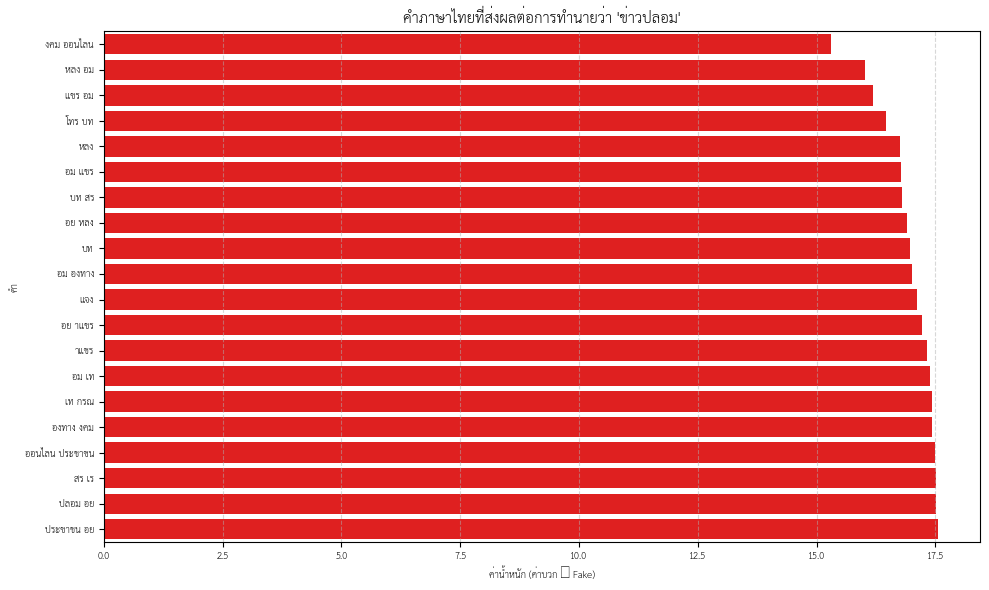

C:\Users\SUPHASET\AppData\Local\Temp\ipykernel_21268\202426654.py:41: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) TH Sarabun New.
  plt.tight_layout()
C:\Users\SUPHASET\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) TH Sarabun New.
  fig.canvas.print_figure(bytes_io, **kw)


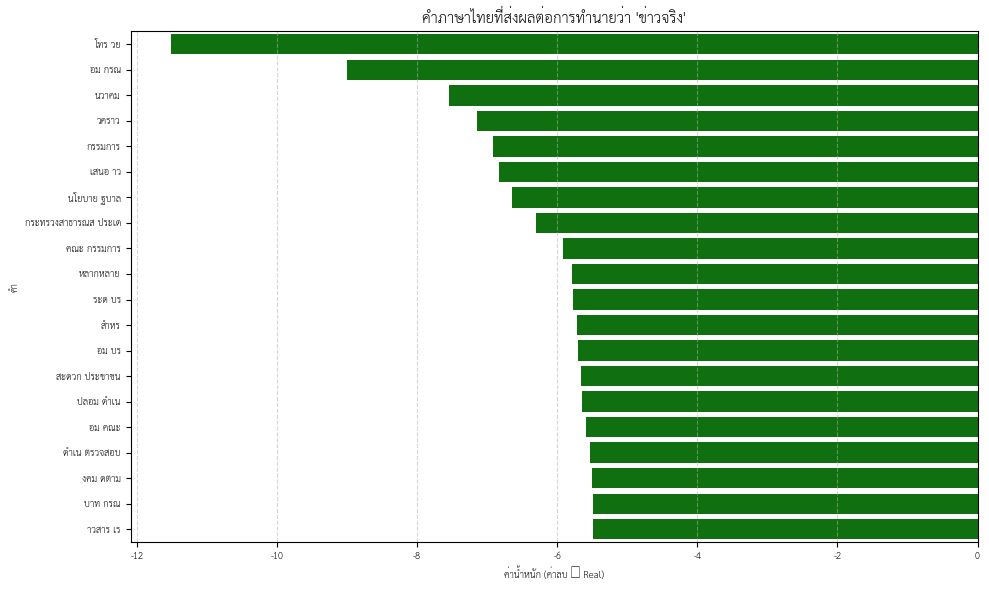

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ====== รวมค่าน้ำหนักทุกชั้นของโมเดล ======
w1, b1 = final_model.layers[0].get_weights()   # Dense(512)
w2, b2 = final_model.layers[1].get_weights()   # Dense(256)
w3, b3 = final_model.layers[3].get_weights()   # Dense(1, sigmoid)

# คำนวณน้ำหนักสุดท้ายจากคำ → output
final_word_importance = np.dot(w1, np.dot(w2, w3)).squeeze()

# ====== ดึงชื่อคำจาก TF-IDF ======
feature_names = np.array(vectorizer.get_feature_names_out())

# ====== หาคำที่มีอิทธิพลสูงสุด ======
top_fake_idx = np.argsort(final_word_importance)[-20:]
top_real_idx = np.argsort(final_word_importance)[:20]

# ====== ตั้งค่าฟอนต์ไทย ======
plt.rcParams['font.family'] = 'TH Sarabun New'
plt.rcParams['axes.unicode_minus'] = False

# ====== กราฟ Fake ======
plt.figure(figsize=(10,6))
sns.barplot(x=final_word_importance[top_fake_idx], y=feature_names[top_fake_idx], color='red')
plt.title("คำภาษาไทยที่ส่งผลต่อการทำนายว่า 'ข่าวปลอม'", fontsize=16)
plt.xlabel("ค่าน้ำหนัก (ค่าบวก → Fake)")
plt.ylabel("คำ")
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ====== กราฟ Real ======
plt.figure(figsize=(10,6))
sns.barplot(x=final_word_importance[top_real_idx], y=feature_names[top_real_idx], color='green')
plt.title("คำภาษาไทยที่ส่งผลต่อการทำนายว่า 'ข่าวจริง'", fontsize=16)
plt.xlabel("ค่าน้ำหนัก (ค่าลบ → Real)")
plt.ylabel("คำ")
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

feature_names = np.array(vectorizer.get_feature_names_out())

# --- ดึงน้ำหนักจาก hidden layer แรก ---
weights, biases = final_model.layers[0].get_weights()

print("Shape ของ weights:", weights.shape)

Shape ของ weights: (10000, 512)


C:\Users\SUPHASET\AppData\Local\Temp\ipykernel_23328\331749025.py:29: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) TH Sarabun New.
  plt.tight_layout()
C:\Users\SUPHASET\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) TH Sarabun New.
  fig.canvas.print_figure(bytes_io, **kw)


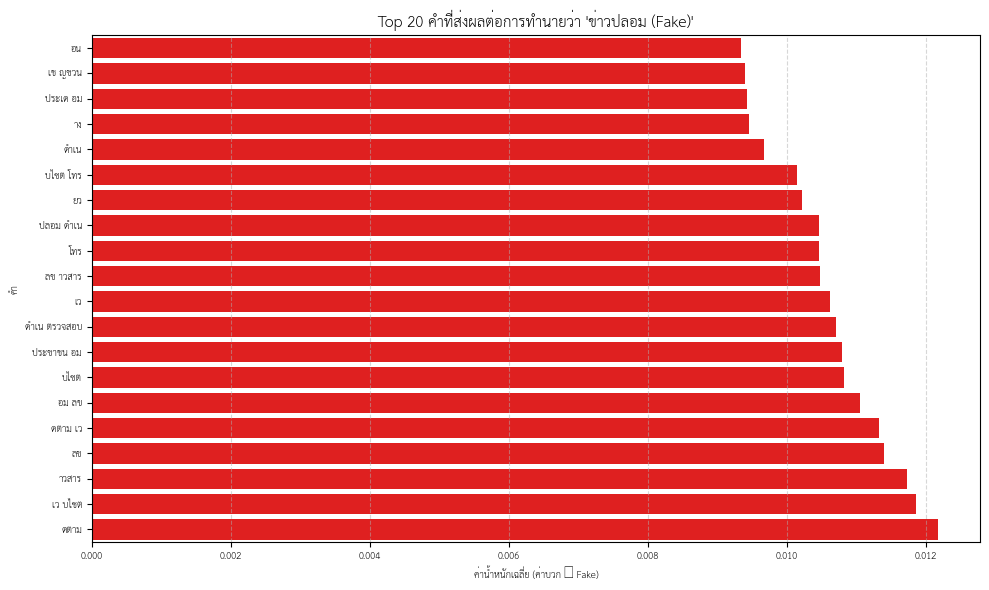

C:\Users\SUPHASET\AppData\Local\Temp\ipykernel_23328\331749025.py:39: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) TH Sarabun New.
  plt.tight_layout()
C:\Users\SUPHASET\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) TH Sarabun New.
  fig.canvas.print_figure(bytes_io, **kw)


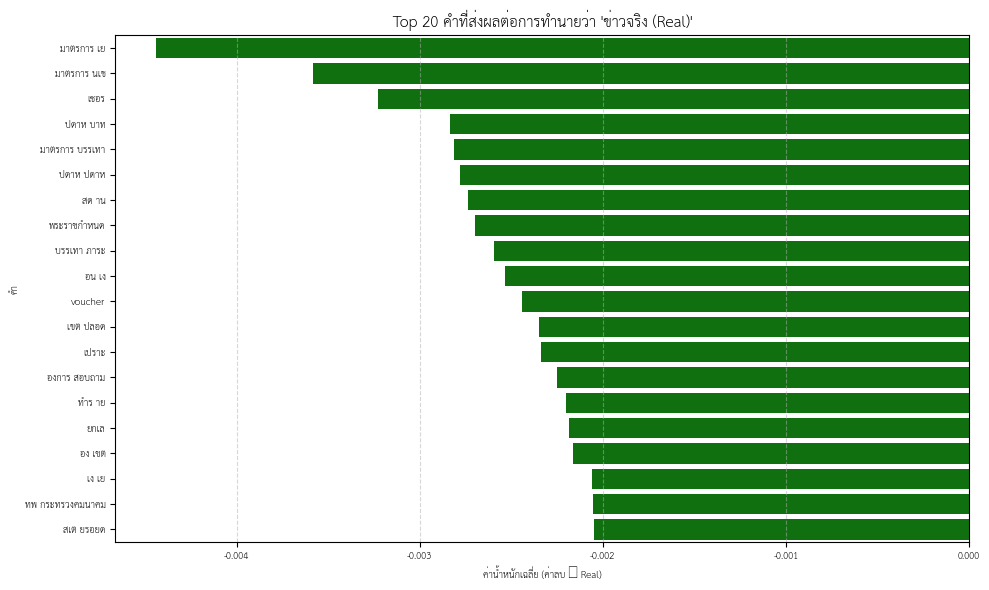

In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# --- ตั้งค่าฟอนต์ภาษาไทย ---
plt.rcParams['font.family'] = 'TH Sarabun New'   # หรือ 'Tahoma', 'Angsana New'
plt.rcParams['axes.unicode_minus'] = False       # ป้องกันเครื่องหมายลบแสดงผิด

# --- คำนวณค่าเฉลี่ยของน้ำหนักแต่ละคำ (รวมทุก neuron) ---
avg_weights = np.mean(weights, axis=1)

# --- เอา top 20 คำที่น้ำหนักสูงสุด (ผลักดันให้เป็น fake) ---
top_fake_idx = np.argsort(avg_weights)[-20:]
top_fake_words = feature_names[top_fake_idx]
top_fake_values = avg_weights[top_fake_idx]

# --- เอา top 20 คำที่น้ำหนักต่ำสุด (ผลักดันให้เป็น real) ---
top_real_idx = np.argsort(avg_weights)[:20]
top_real_words = feature_names[top_real_idx]
top_real_values = avg_weights[top_real_idx]

# --- กราฟ 1: Fake ---
plt.figure(figsize=(10,6))
sns.barplot(x=top_fake_values, y=top_fake_words, color='red')
plt.title("Top 20 คำที่ส่งผลต่อการทำนายว่า 'ข่าวปลอม (Fake)'", fontsize=16)
plt.xlabel("ค่าน้ำหนักเฉลี่ย (ค่าบวก → Fake)")
plt.ylabel("คำ")
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- กราฟ 2: Real ---
plt.figure(figsize=(10,6))
sns.barplot(x=top_real_values, y=top_real_words, color='green')
plt.title("Top 20 คำที่ส่งผลต่อการทำนายว่า 'ข่าวจริง (Real)'", fontsize=16)
plt.xlabel("ค่าน้ำหนักเฉลี่ย (ค่าลบ → Real)")
plt.ylabel("คำ")
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


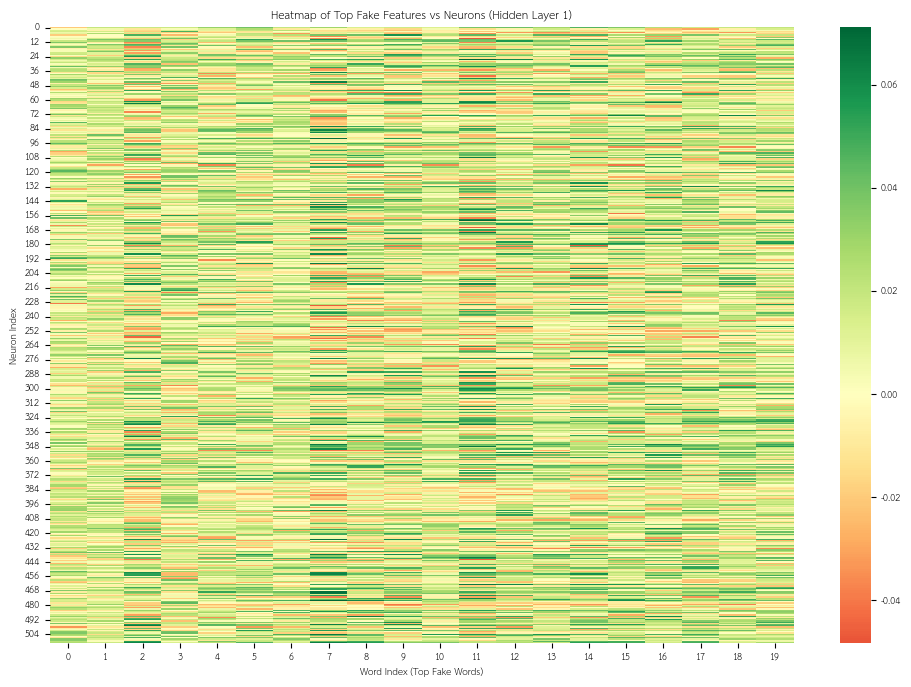

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(weights[top_fake_idx].T, cmap="RdYlGn", center=0)
plt.title("Heatmap of Top Fake Features vs Neurons (Hidden Layer 1)")
plt.xlabel("Word Index (Top Fake Words)")
plt.ylabel("Neuron Index")
plt.show()
